In [4]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
Num GPUs Available: 0


In [5]:
# ============================================================
# 2. Dataset Configuration
# ============================================================

DATASET_PATH = r"D:\Deep Learning\Assignment 3\train"

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 10

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: D:\Deep Learning\Assignment 3\train
Dataset exists: True


In [6]:
# ============================================================
# 2. Dataset Configuration
# ============================================================

DATASET_PATH = r"D:\Deep Learning\Assignment 3\train"

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 10

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: D:\Deep Learning\Assignment 3\train
Dataset exists: True


In [7]:
# ============================================================
# 3. Create DataFrame from Training Images
# ============================================================

DATASET_PATH = r"D:\Deep Learning\Assignment 3\train"

data = []

# Get all image files
file_names = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total image files found:", len(file_names))

# Identify labels from filenames
for filename in file_names:

    filename_lower = filename.lower()

    if filename_lower.startswith("cat"):
        label = "CAT"

    elif filename_lower.startswith("dog"):
        label = "DOG"

    else:
        continue

    data.append({
        "filename": filename,
        "category": label
    })

# Create DataFrame
df = pd.DataFrame(data)

print("\nFirst 5 records:")
print(df.head())

print("\nDataset size:", len(df))

print("\nClass distribution:")
print(df["category"].value_counts())

Total image files found: 1000

First 5 records:
       filename category
0  cat.4001.jpg      CAT
1  cat.4002.jpg      CAT
2  cat.4003.jpg      CAT
3  cat.4004.jpg      CAT
4  cat.4005.jpg      CAT

Dataset size: 1000

Class distribution:
category
CAT    500
DOG    500
Name: count, dtype: int64


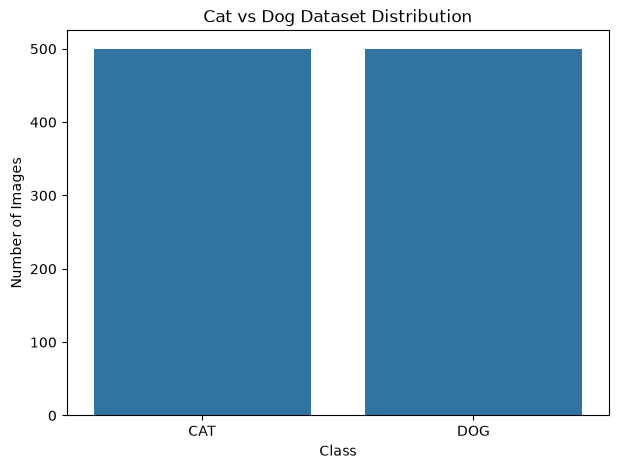

In [8]:
# ============================================================
# 4. Plot Class Distribution
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="category"
)

plt.title("Cat vs Dog Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

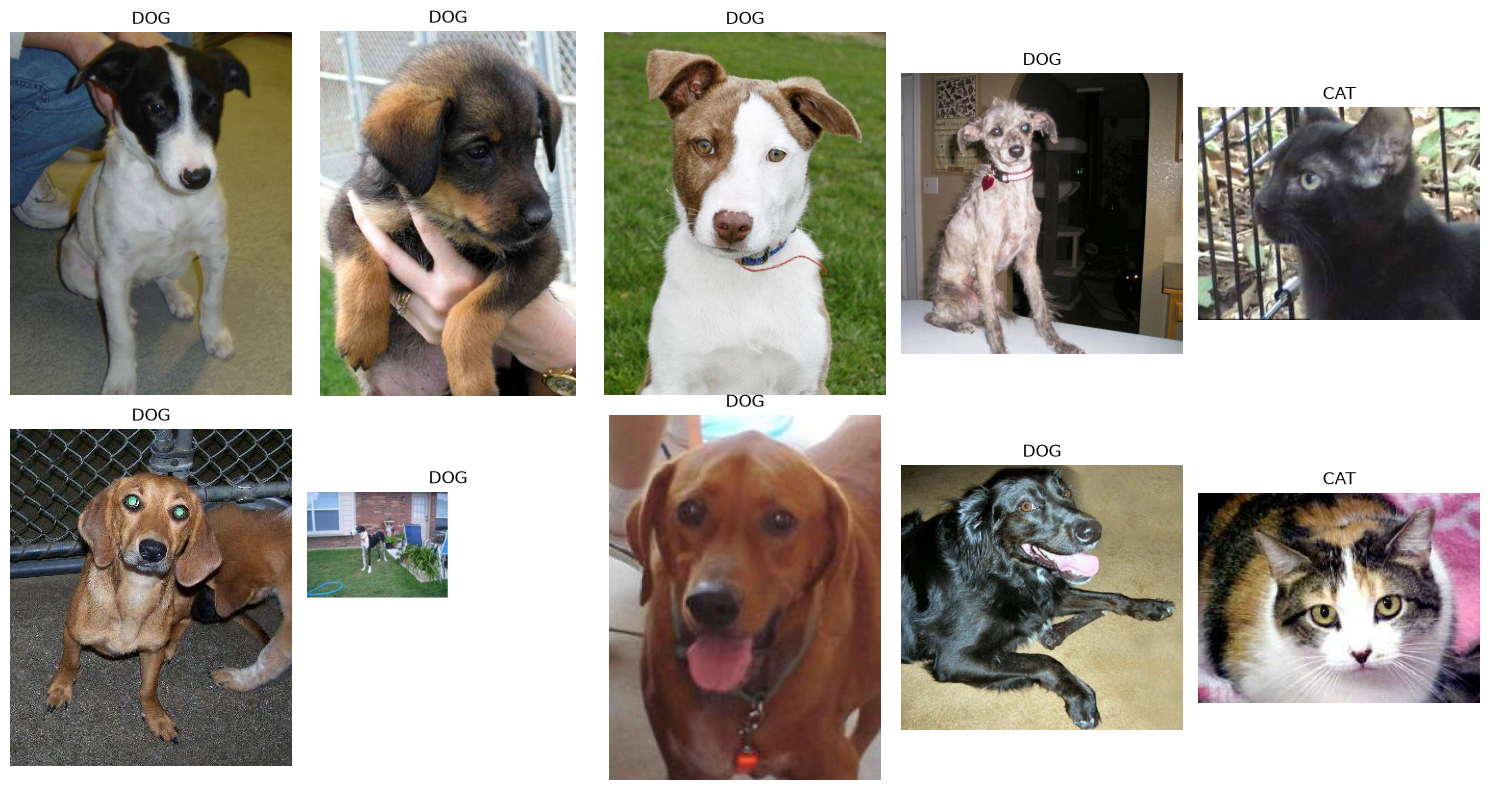

In [9]:
# ============================================================
# 5. Display Sample Images
# ============================================================

from tensorflow.keras.utils import load_img

sample_df = df.sample(10, random_state=42)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image_path = os.path.join(
        DATASET_PATH,
        row["filename"]
    )

    img = load_img(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(row["category"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 6. Train / Validation Split
# ============================================================

train_df, validation_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))

Training images: 800
Validation images: 200


In [11]:
# ============================================================
# 7. Image Data Generators
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [12]:
# ============================================================
# 8. Training Data Generator
# ============================================================

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_PATH,
    x_col="filename",
    y_col="category",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 800 validated image filenames belonging to 2 classes.

Class indices:
{'CAT': 0, 'DOG': 1}


In [13]:
# ============================================================
# 9. Validation Data Generator
# ============================================================

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    directory=DATASET_PATH,
    x_col="filename",
    y_col="category",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Validation samples:", validation_generator.samples)

Found 200 validated image filenames belonging to 2 classes.
Validation samples: 200


In [14]:
# ============================================================
# 10. CNN Model WITHOUT Dropout
# ============================================================

model_no_dropout = models.Sequential([
    
    layers.Input(shape=(64, 64, 3)),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dense(
        128,
        activation="relu"
    ),

    # Binary classification
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_no_dropout.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,224,577 (8.49 MB)

 Trainable params: 2,224,129 (8.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# ============================================================
# 11. Compile CNN WITHOUT Dropout
# ============================================================

model_no_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [16]:
# ============================================================
# 12. Train CNN WITHOUT Dropout
# ============================================================

history_no_dropout = model_no_dropout.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.5700 - loss: 0.9918 - val_accuracy: 0.5500 - val_loss: 0.7006
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.6250 - loss: 0.7205 - val_accuracy: 0.5000 - val_loss: 1.3884
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.6875 - loss: 0.6107 - val_accuracy: 0.5000 - val_loss: 3.9279
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.7100 - loss: 0.5999 - val_accuracy: 0.5000 - val_loss: 3.2229
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.6363 - loss: 0.6355 - val_accuracy: 0.5000 - val_loss: 2.0683
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.6837 - loss: 0.6103 - val_accuracy: 0.5400 - val_loss: 0.8957
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.6975 - loss: 0.6102 - val_accuracy: 0.5650 - val_loss: 0.7984
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.7038 - loss: 0.5772 - val_accuracy: 0.

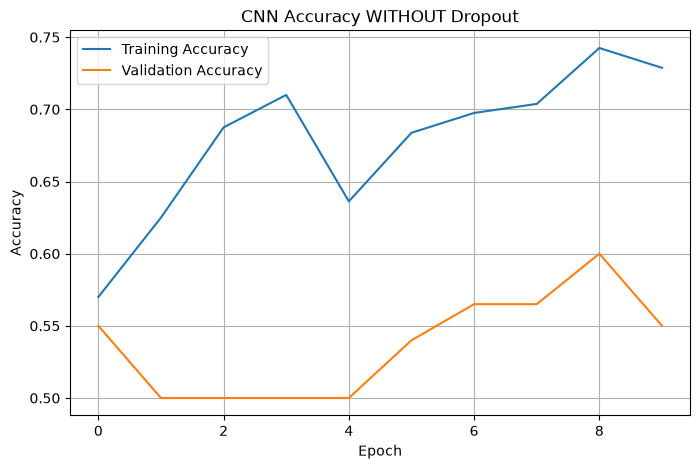

In [17]:
# ============================================================
# 13. Accuracy - WITHOUT Dropout
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_no_dropout.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_no_dropout.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy WITHOUT Dropout")

plt.legend()
plt.grid(True)

plt.show()

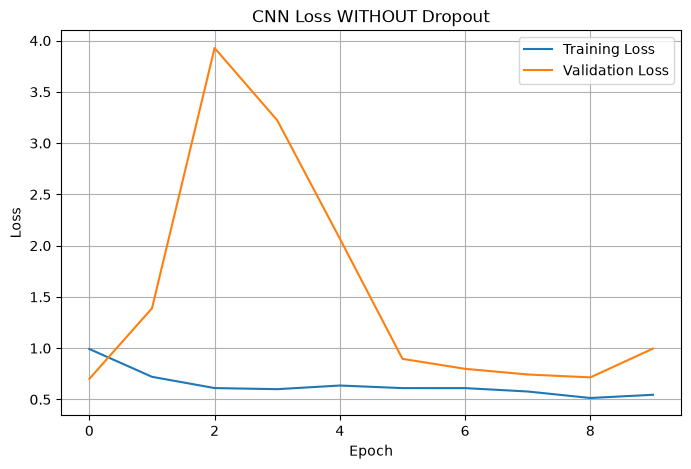

In [18]:
# ============================================================
# 14. Loss - WITHOUT Dropout
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_no_dropout.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_no_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss WITHOUT Dropout")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# ============================================================
# 15. Evaluate CNN WITHOUT Dropout
# ============================================================

loss_no_dropout, accuracy_no_dropout = model_no_dropout.evaluate(
    validation_generator
)

print("Validation Loss:", loss_no_dropout)
print("Validation Accuracy:", accuracy_no_dropout)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5500 - loss: 0.9956
Validation Loss: 0.9956067800521851
Validation Accuracy: 0.550000011920929


In [20]:
# ============================================================
# 16. Classification Report WITHOUT Dropout
# ============================================================

validation_generator.reset()

predictions = model_no_dropout.predict(
    validation_generator
)

predicted_classes = (
    predictions.ravel() >= 0.5
).astype(int)

true_classes = validation_generator.classes

class_names = ["CAT", "DOG"]

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
              precision    recall  f1-score   support

         CAT       0.53      0.94      0.68       100
         DOG       0.73      0.16      0.26       100

    accuracy                           0.55       200
   macro avg       0.63      0.55      0.47       200
weighted avg       0.63      0.55      0.47       200



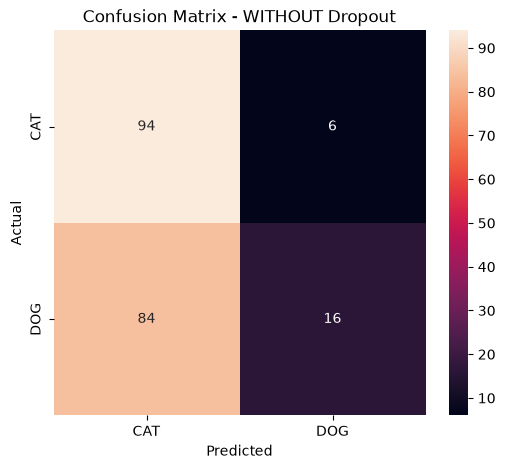

In [21]:
# ============================================================
# 17. Confusion Matrix WITHOUT Dropout
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - WITHOUT Dropout")

plt.show()

In [22]:
# ============================================================
# 18. Save CNN WITHOUT Dropout
# ============================================================

model_no_dropout.save(
    "cat_dog_cnn_no_dropout.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [23]:
# ============================================================
# 19. CNN Model WITH Dropout and L2 Regularization
# ============================================================

model_dropout = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Fully Connected
    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    # Output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,224,577 (8.49 MB)

 Trainable params: 2,224,129 (8.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
# ============================================================
# 20. Compile CNN WITH Dropout
# ============================================================

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Dropout model compiled successfully.")

Dropout model compiled successfully.


In [25]:
# ============================================================
# 21. Train CNN WITH Dropout
# ============================================================

history_dropout = model_dropout.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.5075 - loss: 2.9840 - val_accuracy: 0.5000 - val_loss: 1.5394
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.5375 - loss: 2.0655 - val_accuracy: 0.5000 - val_loss: 1.6458
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.5512 - loss: 1.9169 - val_accuracy: 0.5650 - val_loss: 1.5198
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.5387 - loss: 1.7285 - val_accuracy: 0.5000 - val_loss: 1.6731
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.5050 - loss: 1.6178 - val_accuracy: 0.5400 - val_loss: 1.5347
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.5063 - loss: 1.5184 - val_accuracy: 0.5000 - val_loss: 2.0618
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step - accuracy: 0.5375 - loss: 1.4785 - val_accuracy: 0.5000 - val_loss: 2.1365
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.5775 - loss: 1.4401 - val_accuracy: 0

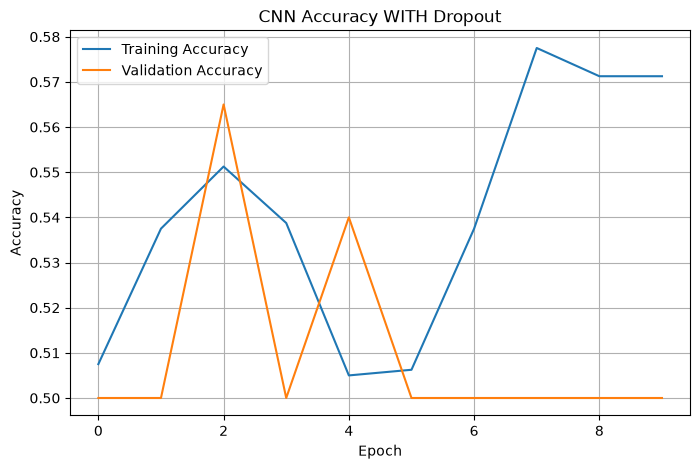

In [26]:
# ============================================================
# 22. Accuracy - WITH Dropout
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN Accuracy WITH Dropout")

plt.legend()
plt.grid(True)

plt.show()

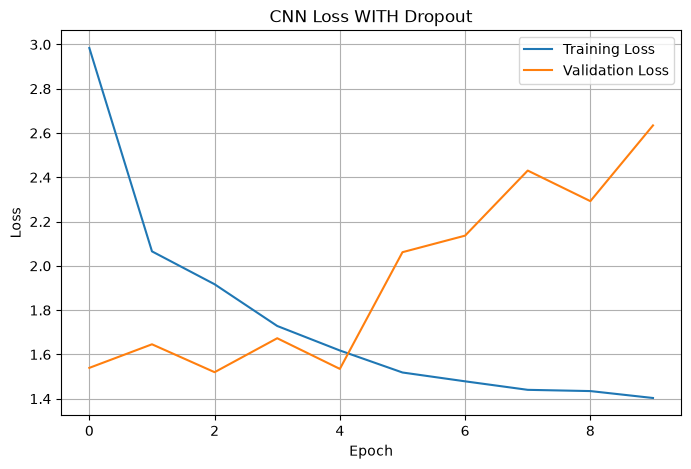

In [27]:
# ============================================================
# 23. Loss - WITH Dropout
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("CNN Loss WITH Dropout")

plt.legend()
plt.grid(True)

plt.show()

In [28]:
# ============================================================
# 24. Evaluate CNN WITH Dropout
# ============================================================

loss_dropout, accuracy_dropout = model_dropout.evaluate(
    validation_generator
)

print("Validation Loss:", loss_dropout)
print("Validation Accuracy:", accuracy_dropout)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 2.6344
Validation Loss: 2.634352922439575
Validation Accuracy: 0.5


In [29]:
# ============================================================
# 25. Classification Report WITH Dropout
# ============================================================

validation_generator.reset()

predictions_dropout = model_dropout.predict(
    validation_generator
)

predicted_classes_dropout = (
    predictions_dropout.ravel() >= 0.5
).astype(int)

true_classes_dropout = validation_generator.classes

print(
    classification_report(
        true_classes_dropout,
        predicted_classes_dropout,
        target_names=class_names
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
              precision    recall  f1-score   support

         CAT       0.50      1.00      0.67       100
         DOG       0.00      0.00      0.00       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



d:\Deep Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Deep Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Deep Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


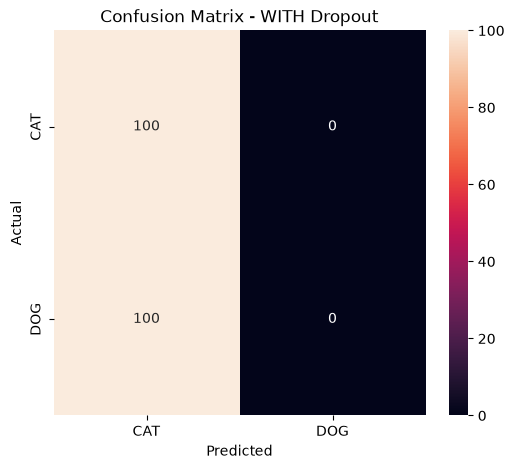

In [30]:
# ============================================================
# 26. Confusion Matrix WITH Dropout
# ============================================================

cm_dropout = confusion_matrix(
    true_classes_dropout,
    predicted_classes_dropout
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dropout,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - WITH Dropout")

plt.show()

In [31]:
# ============================================================
# 27. Save CNN WITH Dropout
# ============================================================

model_dropout.save(
    "cat_dog_cnn_dropout.keras"
)

print("Dropout model saved successfully.")

Dropout model saved successfully.


In [32]:
# ============================================================
# 28. Compare Model Performance
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "CNN WITHOUT Dropout",
        "CNN WITH Dropout + L2"
    ],
    "Validation Accuracy": [
        accuracy_no_dropout,
        accuracy_dropout
    ],
    "Validation Loss": [
        loss_no_dropout,
        loss_dropout
    ]
})

comparison

,Model,Validation Accuracy,Validation Loss
0,CNN WITHOUT Dropout,0.55,0.995607
1,CNN WITH Dropout + L2,0.50,2.634353


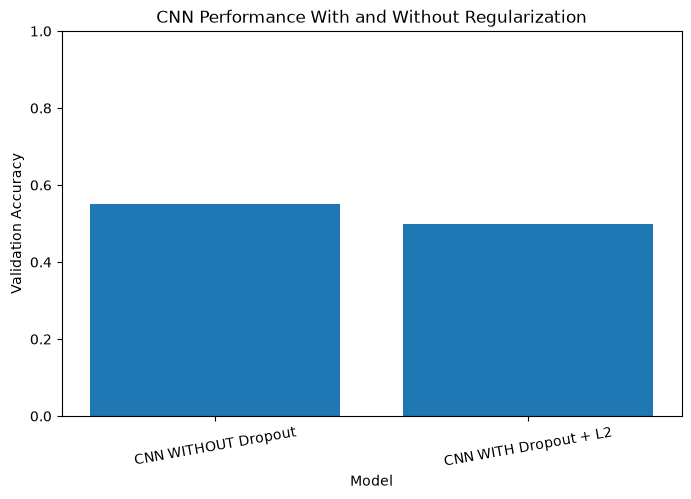

In [33]:
# ============================================================
# 29. Model Accuracy Comparison
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy"]
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model")

plt.title("CNN Performance With and Without Regularization")

plt.ylim(0, 1)

plt.xticks(rotation=10)

plt.show()

In [34]:
# ============================================================
# 30. Select Best Model
# ============================================================

if accuracy_dropout >= accuracy_no_dropout:

    best_model = model_dropout
    best_model_name = "CNN WITH Dropout + L2"

else:

    best_model = model_no_dropout
    best_model_name = "CNN WITHOUT Dropout"

print("Best model:", best_model_name)

Best model: CNN WITHOUT Dropout


In [35]:
# ============================================================
# 31. Save Best Model
# ============================================================

best_model.save(
    "cat_dog_cnn_best.keras"
)

print("Best model saved as cat_dog_cnn_best.keras")

Best model saved as cat_dog_cnn_best.keras


In [37]:
# ============================================================
# 32. Test Single Image
# ============================================================

from tensorflow.keras.utils import load_img, img_to_array

test_image_path = r"D:\Deep Learning\Assignment 3\train\cat.4001.jpg"

img = load_img(
    test_image_path,
    target_size=IMAGE_SIZE
)

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    predicted_label = "DOG"
    confidence = prediction
else:
    predicted_label = "CAT"
    confidence = 1 - prediction

print("Prediction:", predicted_label)
print("Confidence:", f"{confidence * 100:.2f}%")

Prediction: CAT
Confidence: 94.51%


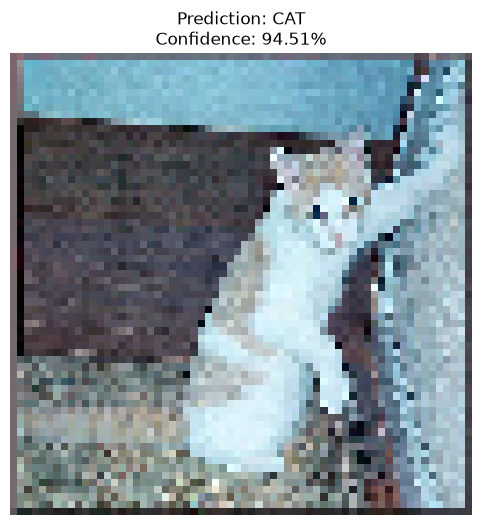

In [38]:
# ============================================================
# 33. Display Prediction
# ============================================================

plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.title(
    f"Prediction: {predicted_label}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()